# Data Loading

In [1]:
# import libraries

import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.proportion import proportions_ztest
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from datetime import datetime

# load the cleaned dataset

df = pd.read_csv("../data/clean_credit_applications.csv")

# Bias Detection

This section investigates whether the loan approval process exhibits systematic disparities across protected attributes. Using statistical tests and fairness metrics, we assess whether approval outcomes differ significantly by gender and age. The objective is to identify potential bias patterns and evaluate fairness risks within the decision-making process.

## Gender Disparate Impact

To evaluate gender-based fairness, we analyze approval rates across gender groups and compute the Disparate Impact (DI) ratio, following the four-fifths rule. Statistical testing and logistic regression are used to determine whether observed differences are significant and whether gender is a meaningful predictor of loan approval outcomes.

### Loan Approval Distribution by Gender

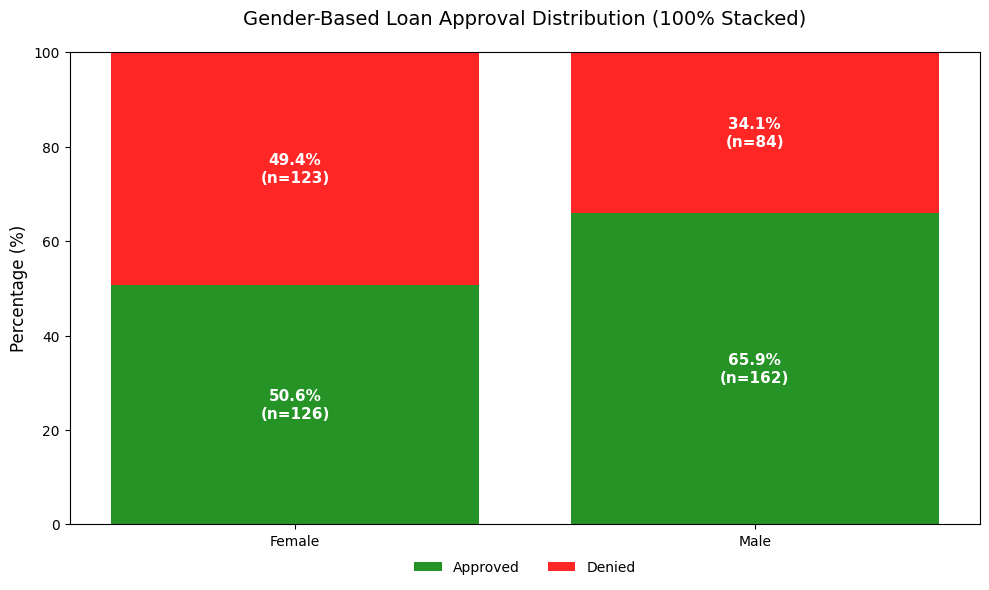

In [18]:
# create a summary variable that groups gender and approval to simplify code reading later on

gender_summary = df.groupby('applicant_info.gender')['decision.loan_approved'].agg(['mean','sum', 'count'])

# prepare the percentages and raw counts

labels = gender_summary.index
approved_pct = gender_summary['mean'] * 100
denied_pct = 100 - approved_pct
approved_cnt = gender_summary['sum']
denied_cnt = gender_summary['count'] - gender_summary['sum']

fig, ax = plt.subplots(figsize=(10, 6))

# create the 100% stacked bars

ax.bar(labels, approved_pct, label='Approved', color='green', alpha=0.85)
ax.bar(labels, denied_pct, bottom=approved_pct, label='Denied', color='red', alpha=0.85)

# add readable labels inside the bars (percentage and count)

for i in range(len(labels)):
    ax.text(
        i,
        approved_pct.iloc[i] / 2,
        f"{approved_pct.iloc[i]:.1f}%\n(n={int(approved_cnt.iloc[i])})",
        ha='center',
        va='center',
        color='white',
        fontweight='bold',
        fontsize=11
    )

    ax.text(
        i,
        approved_pct.iloc[i] + denied_pct.iloc[i] / 2,
        f"{denied_pct.iloc[i]:.1f}%\n(n={int(denied_cnt.iloc[i])})",
        ha='center',
        va='center',
        color='white',
        fontweight='bold',
        fontsize=11
    )

# final details

ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_title('Gender-Based Loan Approval Distribution (100% Stacked)', fontsize=14, pad=20)
ax.set_ylim(0, 100)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=2, frameon=False)

plt.tight_layout()
plt.show()

### Disparate Impact Ratio

**DI = Approval Rate of Unpriviliged Group / Approval Rate of Priviliged Group**


The four-fifth rule is used to evaluate whether a selection process leads to adverse impact against any specific group.

According to the EEOC, a selection rate for any group that is less than four-fifths (or 80%) of the rate for the group with the highest selection rate may indicate adverse impact.

In [4]:
# verify unpriviliged and priviliged group

privileged = gender_summary['mean'].idxmax()    # group with highest approval rate
unprivileged = gender_summary['mean'].idxmin()  # group with lowest approval rate

print("Privileged group:", privileged)
print("Unprivileged group:", unprivileged)

Privileged group: Male
Unprivileged group: Female


In [5]:
# calculate disparate impact ratio

approval_rate_male = gender_summary.loc['Male', 'mean']
approval_rate_female = gender_summary.loc['Female', 'mean']

di = approval_rate_female / approval_rate_male
print("Disparate Impact (Female vs Male):", round(di, 2))

# verify the four-fifths rule

if di < 0.8:
    print("DI < 0.8: potential disparate impact according to the four-fifths rule.")
else:
    print("DI >= 0.8: no strong evidence of disparate impact.")

Disparate Impact (Female vs Male): 0.77
DI < 0.8: potential disparate impact according to the four-fifths rule.


### Proportions Z-Test

Hypothesis testing for gender approval difference:

- H0 = The probability of getting a loan approved is the same for both women and men.
- H1 = The probability of getting a loan approved is not the same for both women and men.

In [17]:
# Z-test

count = [gender_summary.loc['Female', 'sum'], gender_summary.loc['Male', 'sum']]
nobs = [gender_summary.loc['Female', 'count'], gender_summary.loc['Male', 'count']]

stat, pval = proportions_ztest(count, nobs, alternative="two-sided")
print("Z-test p-value for gender approval difference:", round(pval, 4))

# interpretation

if pval < 0.05:
    print("Statistically significant difference detected between groups.")
else:
    print("No statistically significant difference detected.")

Z-test p-value for gender approval difference: 0.0006
Statistically significant difference detected between groups.


### Logistic Regression

In [7]:
# create age 

df['dob'] = pd.to_datetime(df['applicant_info.date_of_birth'], errors='coerce')
today = pd.Timestamp("2024-01-01")

df['age'] = df['dob'].apply(lambda x: today.year - x.year - ((today.month, today.day) < (x.month, x.day)))

# select variables 

df_model = df[
    [
        "decision.loan_approved",
        "applicant_info.gender",
        "age",
        "financials.annual_income",
        "financials.credit_history_months",
        "financials.debt_to_income",
        "financials.savings_balance",
    ]
].copy()

# convert numeric columns safely

numeric_cols = [
    "age",
    "financials.annual_income",
    "financials.credit_history_months",
    "financials.debt_to_income",
    "financials.savings_balance",
]

for col in numeric_cols:
    df_model[col] = pd.to_numeric(df_model[col], errors="coerce")

df_model["decision.loan_approved"] = df_model["decision.loan_approved"].astype(int)

df_model = df_model.dropna()

# encode gender

gender_dummies = pd.get_dummies(
    df_model["applicant_info.gender"],
    prefix="gender",
    drop_first=True
)

X = pd.concat([df_model[numeric_cols], gender_dummies], axis=1)
X = sm.add_constant(X)
y = df_model["decision.loan_approved"]


# force pure numeric arrays (fixes dtype issue)

X_np = X.astype(float).to_numpy()
y_np = y.astype(float).to_numpy()

# fit logistic regression

model = sm.Logit(y_np, X_np).fit(disp=False)
print(model.summary())

# reattach column names for interpretation

X_cols = X.columns
params = pd.Series(model.params, index=X_cols)
pvals  = pd.Series(model.pvalues, index=X_cols)

gender_cols = [c for c in X_cols if c.startswith("gender_")]

print("\n Gender Terms:")
print(pd.DataFrame({
    "coef": params[gender_cols],
    "p_value": pvals[gender_cols],
    "odds_ratio": np.exp(params[gender_cols])
}))

# interpretation

alpha = 0.05
sig = pvals[gender_cols][pvals[gender_cols] < alpha]

print("\n Interpretation:")

if len(sig) > 0:
    top = sig.sort_values().index[0]
    OR = float(np.exp(params[top]))
    p = float(pvals[top])

    print(
        "Even controlling for financial risk indicators "
        "(annual income, credit history months, debt-to-income, savings balance) "
        "and age, gender remains a statistically significant predictor of approval "
        f"({top}: OR={OR:.2f}, p={p:.4g}). \n"
        "This suggests potential discriminatory bias that warrants further governance review."
    )
else:
    print(
        "After controlling for financial risk indicators and age, gender is not a statistically "
        "significant predictor of approval. This suggests the raw disparity may be explained "
        "by differences in observed financial risk factors rather than direct gender-based bias."
    )

                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                  495
Model:                          Logit   Df Residuals:                      488
Method:                           MLE   Df Model:                            6
Date:                Mon, 02 Mar 2026   Pseudo R-squ.:                 0.05384
Time:                        16:13:09   Log-Likelihood:                -318.34
converged:                       True   LL-Null:                       -336.45
Covariance Type:            nonrobust   LLR p-value:                 2.489e-06
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.3829      0.442     -3.132      0.002      -2.248      -0.517
x1            -0.0055      0.012     -0.455      0.649      -0.029       0.018
x2          1.228e-05   4.72e-06      2.599      0.0

## Age-based discrimination patterns

We examine whether loan approval outcomes vary across age groups and across continuous age values. Using visual analysis, chi-square testing, and logistic regression, we assess whether age is statistically associated with approval decisions and whether patterns suggest potential age-based disparity.

### Age-Based Approval Composition with Linear Trendline

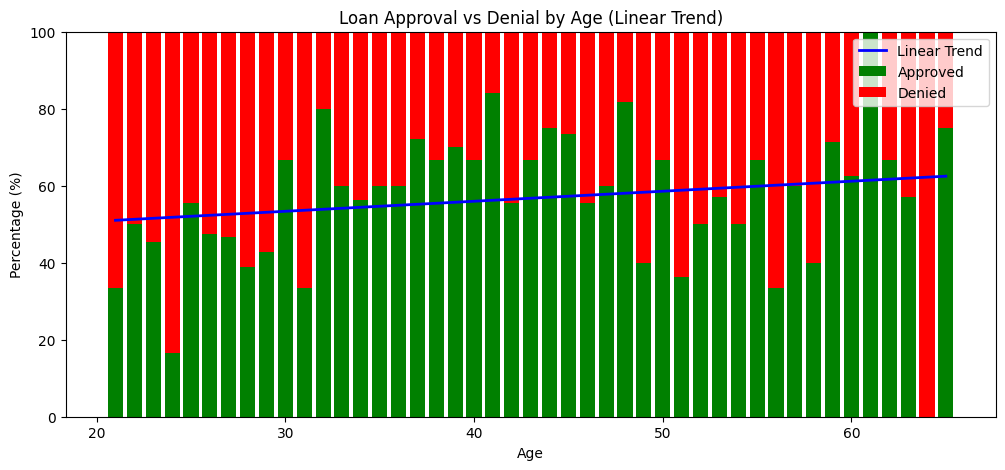

In [8]:
# create a age summary and make sure it is sorted

age_summary = df.groupby('age')['decision.loan_approved'].agg(['mean','sum', 'count'])
age_summary = age_summary.sort_index()

# create approval and denial rate in percentage

age_summary['approval_%'] = age_summary['mean'] * 100
age_summary['denial_%'] = 100 - age_summary['approval_%']

# create a linear regression for tendency

X = age_summary.index.values.reshape(-1,1)
Y = age_summary['approval_%'].values

model = LinearRegression()
model.fit(X, Y)

trend = model.predict(X)

# plot 100% stacked bar with linear trend 

plt.figure(figsize=(12,5))
plt.bar(age_summary.index, age_summary['approval_%'], label='Approved', color='green')
plt.bar(age_summary.index, age_summary['denial_%'], bottom=age_summary['approval_%'], label='Denied', color='red')

plt.plot(age_summary.index, trend, color='blue', linewidth=2, label='Linear Trend')

plt.xlabel('Age')
plt.ylabel('Percentage (%)')
plt.title('Loan Approval vs Denial by Age (Linear Trend)')
plt.legend()
plt.ylim(0,100)
plt.show()

### Logistic Regression

In [19]:
# create logit regression

X = df[['age']]   
y = df['decision.loan_approved']

X = sm.add_constant(X)  # add intercept


logit_model = sm.Logit(y, X).fit()
print(logit_model.summary())

# extract coefficient and p-value for age

coef_age = logit_model.params['age']
p_value_age = logit_model.pvalues['age']

# odds ratio

odds_ratio = np.exp(coef_age)

#  interpretation

if p_value_age < 0.05:
    significance = "statistically significant"
else:
    significance = "not statistically significant"

if odds_ratio > 1:
    direction = "increase"
elif odds_ratio < 1:
    direction = "decrease"
else:
    direction = "no change"

interpretation = (
    f"\nLogistic regression results for age predicting loan approval:\n"
    f"- Coefficient for age: {coef_age:.3f}\n"
    f"- Odds ratio: {odds_ratio:.3f}\n"
    f"- P-value: {p_value_age:.3f} → {significance}\n"
    f"\nInterpretation:\n"
)

if p_value_age < 0.05:
    interpretation += (
        f"Age is a statistically significant predictor of loan approval.\n"
        f"Each additional year of age is associated with a {direction} in the odds of approval "
        f"(odds multiplied by {odds_ratio:.3f} per year).\n"
        f"This suggests potential age-based disparity, though financial controls must be considered."
    )
else:
    interpretation += (
        f"Age is not a statistically significant predictor of loan approval.\n"
        f"There is no strong statistical evidence of age-based disparity at the 5% significance level."
    )

print(interpretation)

Optimization terminated successfully.
         Current function value: 0.672151
         Iterations 4
                             Logit Regression Results                             
Dep. Variable:     decision.loan_approved   No. Observations:                  495
Model:                              Logit   Df Residuals:                      493
Method:                               MLE   Df Model:                            1
Date:                    Mon, 02 Mar 2026   Pseudo R-squ.:                 0.01110
Time:                            16:20:18   Log-Likelihood:                -332.71
converged:                           True   LL-Null:                       -336.45
Covariance Type:                nonrobust   LLR p-value:                  0.006267
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.5569      0.339     -1.641      0.101      -1.222       0.1

### Bins

In [10]:
# create meaningful age brackets

bins = [18, 25, 40, 60, 100]
labels = ['Gen Z (18-25)', 'Millennials (26-40)', 'Gen X (41-60)', 'Seniors (60+)']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

# create a contingency table (counts of approved vs denied per age group)

contingency_table = pd.crosstab(df['age_group'], df['decision.loan_approved'])

print(contingency_table)

decision.loan_approved  False  True 
age_group                           
Gen Z (18-25)              28     14
Millennials (26-40)       104    139
Gen X (41-60)              65    115
Seniors (60+)              10     20


#### Chi-Square test

Hypothesis testing for age-based discrimination:
- H0: Age group and loan approval are independent
- H1: Age group and loan approval are not independent

In [11]:
# Chi-Square test

chi2, pval, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-Square Test p-value: {pval:.6f}")

# interpretation

if pval < 0.05:
    print("There is a statistically significant association between age group and loan approval status.")
else:
    print("No statistically significant association between age group and loan approval status was detected.")

Chi-Square Test p-value: 0.002836
There is a statistically significant association between age group and loan approval status.


#### Loan Approval Distribution by Age Group

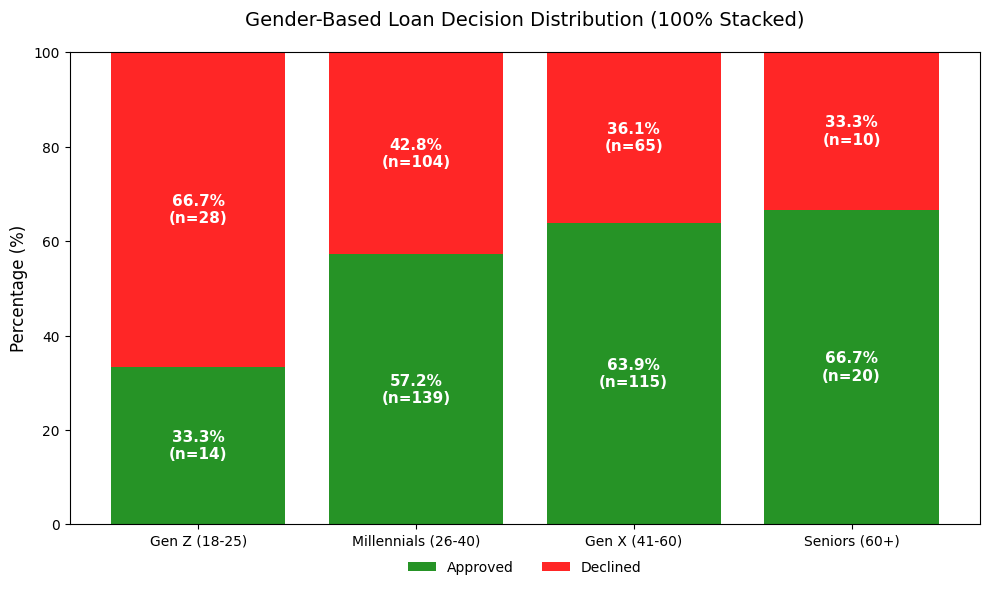

In [22]:
# compute percentage distribution per age group

contingency_table_percent = contingency_table.div(contingency_table.sum(axis=1), axis=0) * 100


# sort columns so approval comes first

contingency_table_percent = contingency_table_percent.sort_index(axis=1, ascending=False)

# rename for easier reading

contingency_table_percent = contingency_table_percent.rename(
    columns={True: "Approved", False: "Declined", "True": "Approved", "False": "Declined"}
)

# add label

labels = contingency_table_percent.index
approved_pct = contingency_table_percent["Approved"]
declined_pct = contingency_table_percent["Declined"]

approved_cnt = contingency_table["Approved"]
declined_cnt = contingency_table["Declined"]

fig, ax = plt.subplots(figsize=(10, 6))

# 100% stacked bars 
ax.bar(labels, approved_pct, label="Approved", color="green", alpha=0.85)
ax.bar(labels, declined_pct, bottom=approved_pct, label="Declined", color="red", alpha=0.85)

# labels inside bars 
for i in range(len(labels)):
    ax.text(
        i, approved_pct.iloc[i] / 2,
        f"{approved_pct.iloc[i]:.1f}%\n(n={int(approved_cnt.iloc[i])})",
        ha="center", va="center", color="white", fontweight="bold", fontsize=11
    )

    ax.text(
        i, approved_pct.iloc[i] + declined_pct.iloc[i] / 2,
        f"{declined_pct.iloc[i]:.1f}%\n(n={int(declined_cnt.iloc[i])})",
        ha="center", va="center", color="white", fontweight="bold", fontsize=11
    )

# final details

ax.set_ylabel("Percentage (%)", fontsize=12)
ax.set_title("Gender-Based Loan Decision Distribution (100% Stacked)", fontsize=14, pad=20)
ax.set_ylim(0, 100)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.05), ncol=2, frameon=False)

plt.tight_layout()
plt.show()

## Proxy variables for protected attributes

Even when protected attributes such as gender or age are not explicitly used in a decision model, other variables may act as proxies if they are strongly correlated with those attributes. These proxy variables can indirectly reproduce discriminatory patterns.

In this section, we examine whether non-protected features (e.g., ZIP code, income, spending behavior) are associated with protected attributes and may therefore pose fairness risks in the credit approval process.

### Proxy Variable Screening with Correlation Analysis

In [13]:
import numpy as np
import pandas as pd

numeric_vars = [
    'financials.annual_income',
    'financials.credit_history_months',
    'financials.debt_to_income',
    'financials.savings_balance'
]

# Gender and Age are treated as protected attributes in this audit context

# Make sure numeric vars are numeric

for col in numeric_vars:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["age"] = pd.to_numeric(df["age"], errors="coerce")

# encode gender as a binary indicator 

df['gender_binary'] = (df['applicant_info.gender'] == 'Male').astype(int)

# drop rows with missing values for clean correlations

df_corr = df[numeric_vars + ['gender_binary', 'age']].dropna()

# correlation of gender

corr_gender = df_corr[numeric_vars + ['gender_binary']].corr(numeric_only=True)['gender_binary'].drop('gender_binary')
corr_gender = corr_gender.sort_values(ascending=False)

print("Correlation with gender_binary (1 = Male, 0 = not Male):")
print(corr_gender)

# interpretation

max_abs_gender = float(corr_gender.abs().max()) if len(corr_gender) else np.nan

print("\n--- Interpretation (Gender Proxy Risk) ---")
if pd.isna(max_abs_gender):
    print("Could not compute correlations (check missing values).")
elif max_abs_gender < 0.10:
    print(f"All correlations are very small (max |r| = {max_abs_gender:.3f}). "
          "These financial variables do not show meaningful proxy behavior for gender.")
elif max_abs_gender < 0.30:
    print(f"Some correlations are weak (max |r| = {max_abs_gender:.3f}). "
          "There may be mild proxy risk; investigate the top variable(s) further.")
else:
    print(f"At least one correlation is moderate/strong (max |r| = {max_abs_gender:.3f}). "
          "This suggests potential proxy behavior for gender; deeper analysis is recommended.")

# correlation of age

corr_age = df_corr[numeric_vars + ['age']].corr(numeric_only=True)['age'].drop('age')
corr_age = corr_age.sort_values(ascending=False)

print("\nCorrelation with age (continuous):")
print(corr_age)

# interpretation

max_abs_age = float(corr_age.abs().max()) if len(corr_age) else np.nan

print("\n--- Interpretation (Age Proxy Risk) ---")
if pd.isna(max_abs_age):
    print("Could not compute correlations (check missing values).")
elif max_abs_age < 0.10:
    print(f"All correlations are very small (max |r| = {max_abs_age:.3f}). "
          "These financial variables do not show meaningful proxy behavior for age.")
elif max_abs_age < 0.30:
    print(f"Some correlations are weak (max |r| = {max_abs_age:.3f}). "
          "There may be mild proxy risk for age; investigate the top variable(s) further.")
else:
    print(f"At least one correlation is moderate/strong (max |r| = {max_abs_age:.3f}). "
          "This suggests potential proxy behavior for age.")

Correlation with gender_binary (1 = Male, 0 = not Male):
financials.debt_to_income           0.020017
financials.savings_balance          0.003691
financials.credit_history_months   -0.020249
financials.annual_income           -0.041124
Name: gender_binary, dtype: float64

--- Interpretation (Gender Proxy Risk) ---
All correlations are very small (max |r| = 0.041). These financial variables do not show meaningful proxy behavior for gender.

Correlation with age (continuous):
financials.credit_history_months    0.649444
financials.annual_income            0.393244
financials.savings_balance          0.286059
financials.debt_to_income          -0.013078
Name: age, dtype: float64

--- Interpretation (Age Proxy Risk) ---
At least one correlation is moderate/strong (max |r| = 0.649). This suggests potential proxy behavior for age.


### Logistic Regression

In [14]:
# select variables

cols = [
    "decision.loan_approved",
    "age",
    "financials.credit_history_months",
    "financials.annual_income",
    "financials.savings_balance",
    "financials.debt_to_income",
]
df_proxy = df[cols].copy()

# coerce numeric types safely

for c in cols:
    if c != "decision.loan_approved":
        df_proxy[c] = pd.to_numeric(df_proxy[c], errors="coerce")

# ensure binary target 0/1

df_proxy["decision.loan_approved"] = df_proxy["decision.loan_approved"].astype(int)

# drop missing rows

df_proxy = df_proxy.dropna()

# model A: approval ~ financial variables , WITHOUT age

X_A = df_proxy[
    [
        "financials.credit_history_months",
        "financials.annual_income",
        "financials.savings_balance",
        "financials.debt_to_income",
    ]
]
X_A = sm.add_constant(X_A)
y = df_proxy["decision.loan_approved"]

model_A = sm.Logit(y, X_A).fit(disp=False)

print("Model A (WITHOUT age): approval ~ financial variables")
print(model_A.summary())

# model B: approval ~ financial variables + age 

X_B = df_proxy[
    [
        "age",
        "financials.credit_history_months",
        "financials.annual_income",
        "financials.savings_balance",
        "financials.debt_to_income",
    ]
]
X_B = sm.add_constant(X_B)

model_B = sm.Logit(y, X_B).fit(disp=False)

print("\n Model B (WITH age): approval ~ age + financial variables")
print(model_B.summary())

# interpretation

alpha = 0.05

# extract key terms we care about

terms_A = ["financials.credit_history_months", "financials.annual_income", "financials.savings_balance", "financials.debt_to_income"]
terms_B = ["age"] + terms_A

params_A = model_A.params
pvals_A = model_A.pvalues

params_B = model_B.params
pvals_B = model_B.pvalues

# odds ratios

or_A = np.exp(params_A[terms_A])
or_B = np.exp(params_B[terms_B])

# cocus proxy candidate most correlated with age from your earlier step

proxy_focus = "financials.credit_history_months"

# coefficient change for proxy_focus when adding age

coef_A = float(params_A[proxy_focus])
coef_B = float(params_B[proxy_focus])
pct_change = np.nan
if coef_A != 0:
    pct_change = (coef_B - coef_A) / abs(coef_A) * 100

# significance flags

proxy_sig_A = float(pvals_A[proxy_focus]) < alpha
proxy_sig_B = float(pvals_B[proxy_focus]) < alpha
age_sig_B = float(pvals_B["age"]) < alpha

print("\n Key effects (Odds Ratios)")
print("Model A ORs:")
print(or_A.round(4))

print("\nModel B ORs:")
print(or_B.round(4))

print("\n Interpretation:")

# 1) Does the proxy candidate predict approval?

if proxy_sig_A:
    print(f"- {proxy_focus} significantly predicts approval in Model A (p={float(pvals_A[proxy_focus]):.4g}).")
else:
    print(f"- {proxy_focus} is NOT significant in Model A (p={float(pvals_A[proxy_focus]):.4g}); weaker evidence it drives outcomes.")

# 2) Does age matter once financials are included?

if age_sig_B:
    print(f"- Age remains significant after controlling for financial variables (p={float(pvals_B['age']):.4g}).")
else:
    print(f"- Age is NOT significant after controlling for financial variables (p={float(pvals_B['age']):.4g}).")

# 3) Does adding age change the proxy coefficient meaningfully?

if pd.notna(pct_change):
    change_abs = abs(pct_change)
    if change_abs >= 25:
        change_text = "substantial"
    elif change_abs >= 10:
        change_text = "noticeable"
    else:
        change_text = "small"
    print(f"- Adding age changes the {proxy_focus} coefficient by {pct_change:.1f}% ({change_text} change).")
else:
    print(f"- Could not compute percent change for {proxy_focus} (coefficient in Model A was zero).")

# conclusion

print("\n Proxy Discrimination Conclusion (Age):")

if proxy_sig_A and (abs(pct_change) >= 10) and (not age_sig_B):
    print(
        "Proxy discrimination likely present: the proxy variable predicts approval, and once age is added, "
        "the age term becomes non-significant while the proxy coefficient shifts meaningfully. "
        "This supports the interpretation that age-related information is indirectly encoded via financial indicators "
        "(especially credit history), creating potential indirect age-based disparity."
    )

elif proxy_sig_A and age_sig_B:
    print(
        "Evidence of age-based effect beyond proxies: the proxy variable predicts approval AND age remains statistically significant "
        "after controlling for financial indicators. This suggests the age-related pattern is not fully explained by observed risk variables, "
        "strengthening concerns about potential age-related unfairness and warranting deeper governance review."
    )

elif (not proxy_sig_A) and (not age_sig_B):
    print(
        "Proxy discrimination not supported in this test: neither age nor the main proxy candidate (credit history months) shows "
        "statistically significant effects. Based on this model alone, there is limited evidence of age-related proxy discrimination "
        "through the selected financial variables."
    )

else:
    print(
        "Proxy discrimination inconclusive: some variables predict approval, but the mediation/proxy pattern is not definitive "
        "(e.g., weak coefficient shift or inconsistent significance). To confirm proxy risk, test additional candidate proxies "
        "(ZIP code, spending categories, loan purpose) and compare outcomes across those proxy groups."
    )

Model A (WITHOUT age): approval ~ financial variables
                             Logit Regression Results                             
Dep. Variable:     decision.loan_approved   No. Observations:                  495
Model:                              Logit   Df Residuals:                      490
Method:                               MLE   Df Model:                            4
Date:                    Mon, 02 Mar 2026   Pseudo R-squ.:                 0.03314
Time:                            16:13:09   Log-Likelihood:                -325.30
converged:                           True   LL-Null:                       -336.45
Covariance Type:                nonrobust   LLR p-value:                 0.0001748
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const                               -1.0758      0.355     -3.030      0.002    

## Interaction effects between attributes

This section examines whether the combined effect of protected attributes leads to compounded disparities in loan approval outcomes. Specifically, we assess whether the impact of age on approval differs by gender, or whether gender disparities vary across age groups. By testing interaction effects, we evaluate the presence of potential intersectional bias, where overlapping characteristics may amplify or modify fairness risks beyond their individual effects.

### Logistic Regression

In [15]:
# keep only relevant variables

df_int = df[["decision.loan_approved", "age", "applicant_info.gender"]].copy().dropna()

# ensure numeric

df_int["decision.loan_approved"] = df_int["decision.loan_approved"].astype(int)
df_int["age"] = pd.to_numeric(df_int["age"], errors="coerce")
df_int = df_int.dropna()

# one-hot encode gender

gender_dummies = pd.get_dummies(df_int["applicant_info.gender"], prefix="gender", drop_first=True)

# main effects

X = pd.concat([df_int[["age"]], gender_dummies], axis=1)

# interaction terms: age * each gender dummy

for col in gender_dummies.columns:
    X[f"age:{col}"] = df_int["age"] * gender_dummies[col]

X = sm.add_constant(X)
y = df_int["decision.loan_approved"]


# pure numeric arrays to solver previous issues

X_cols = X.columns
X_np = X.astype(float).to_numpy()
y_np = y.astype(float).to_numpy()

model = sm.Logit(y_np, X_np).fit(disp=False)
print(model.summary())

# reattach names for interpretation

params = pd.Series(model.params, index=X_cols)
pvals  = pd.Series(model.pvalues, index=X_cols)

alpha = 0.05
interaction_cols = [c for c in X_cols if c.startswith("age:")]

print("\n Interaction Terms (Age * Gender):")
if len(interaction_cols) == 0:
    print("No interaction columns created (check gender categories).")
else:
    for term in interaction_cols:
        coef = float(params[term])
        pval = float(pvals[term])
        OR = float(np.exp(coef))
        print(f"{term}: coef={coef:.4f}, OR={OR:.3f}, p={pval:.4g}")

    any_sig = bool((pvals[interaction_cols] < alpha).any())

    print("\n Interpretation:")
    if any_sig:
        top_term = pvals[interaction_cols].sort_values().index[0]
        top_p = float(pvals[top_term])
        top_or = float(np.exp(params[top_term]))
        print(
            "Interaction detected: at least one age * gender interaction term is statistically significant.\n"
            f"- Most significant term: {top_term} (OR={top_or:.3f}, p={top_p:.4g}).\n"
            "This suggests the effect of age on loan approval differs across gender groups (potential intersectional disparity)."
        )
    else:
        print(
            "No interaction detected: age * gender interaction terms are not statistically significant.\n"
            "This suggests the effects of age and gender operate independently in this dataset."
        )

                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                  495
Model:                          Logit   Df Residuals:                      491
Method:                           MLE   Df Model:                            3
Date:                Mon, 02 Mar 2026   Pseudo R-squ.:                 0.02905
Time:                        16:13:09   Log-Likelihood:                -326.68
converged:                       True   LL-Null:                       -336.45
Covariance Type:            nonrobust   LLR p-value:                 0.0002106
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.9411      0.463     -2.034      0.042      -1.848      -0.034
x1             0.0251      0.012      2.165      0.030       0.002       0.048
x2             0.7664      0.690      1.111      0.2